In [1]:
# Importing the required libraries
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import sys

In [2]:
df = pd.read_csv("heart_v2.csv")

In [3]:
df.head()

,age,sex,BP,cholestrol,heart disease
0,70,1,130,322,1
1,67,0,115,564,0
2,57,1,124,261,1
3,64,1,128,263,0
4,74,0,120,269,0


In [25]:
df["cholestrol"].sum()

np.int64(67408)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   age            270 non-null    int64
 1   sex            270 non-null    int64
 2   BP             270 non-null    int64
 3   cholestrol     270 non-null    int64
 4   heart disease  270 non-null    int64
dtypes: int64(5)
memory usage: 10.7 KB


<Axes: ylabel='count'>

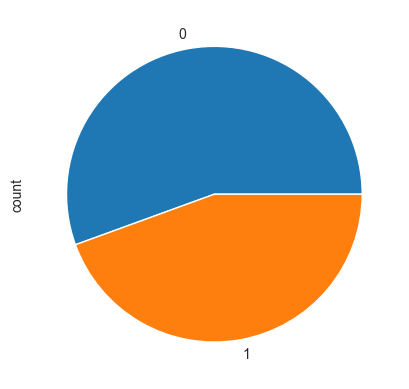

In [27]:
df["heart disease"].value_counts().plot.pie()

In [6]:
# train test split
from sklearn.model_selection import train_test_split

X = df.drop("heart disease", axis=1)
y = df["heart disease"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, random_state=42
)

In [7]:
print(X_train.head())
print(X_test.head())

     age  sex   BP  cholestrol
84    57    1  110         201
251   44    1  130         219
92    54    1  124         266
201   58    1  125         300
126   62    1  120         267
     age  sex   BP  cholestrol
30    57    1  128         229
116   46    1  120         249
79    56    1  120         236
127   52    0  136         196
196   58    0  100         248


## Decision Tree Building


In [8]:
from sklearn.tree import DecisionTreeClassifier

In [9]:
dt = DecisionTreeClassifier(max_depth=3)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [10]:
from IPython.display import Image
from six import StringIO
from sklearn.tree import export_graphviz
import pydotplus, graphviz

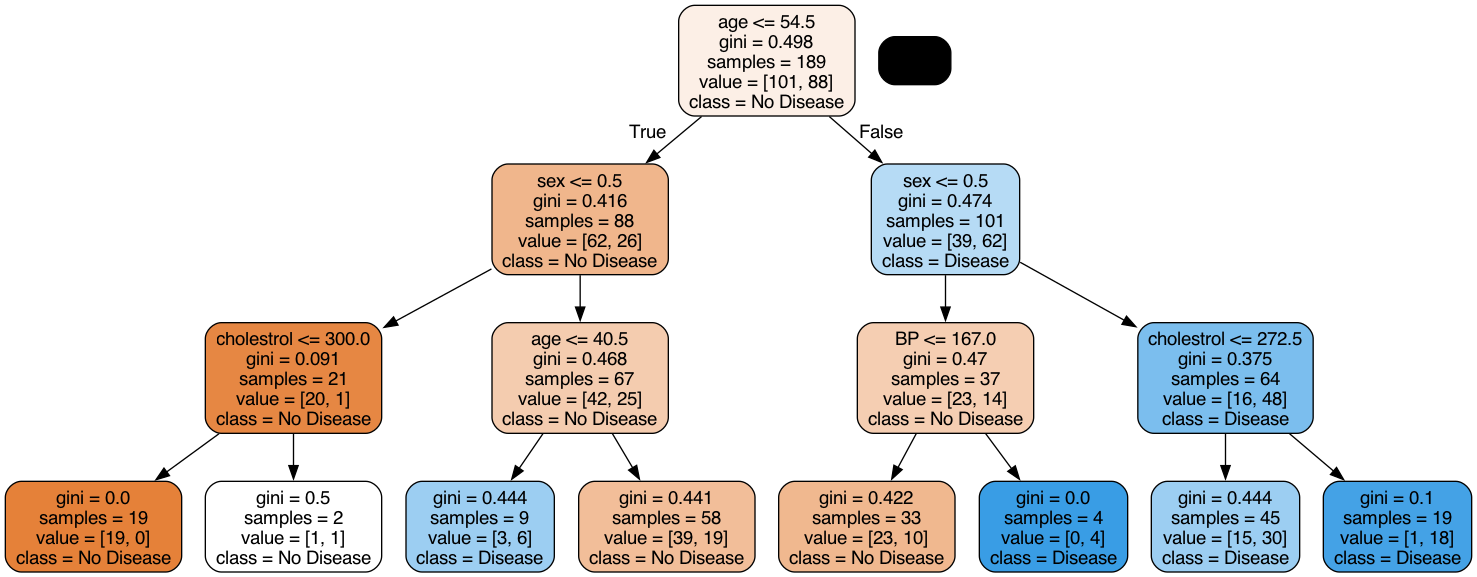

In [11]:
dot_data = StringIO()
export_graphviz(
    dt,
    out_file=dot_data,
    filled=True,
    rounded=True,
    feature_names=X.columns,
    class_names=["No Disease", "Disease"],
)  # creates a graphviz object and puts in dot_data
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

In [12]:
from PIL import Image as img

# img.Image.save('graph.png',graph.create_png())

In [13]:
y_train_pred = dt.predict(X_train)
y_test_pred = dt.predict(X_test)

In [14]:
from sklearn import metrics

print(f"Train accuracy: {metrics.accuracy_score(y_train, y_train_pred)}")
print(f"Test accuracy: {metrics.accuracy_score(y_test, y_test_pred)}")

Train accuracy: 0.7407407407407407
Test accuracy: 0.6049382716049383


In [15]:
import sys

sys.version_info

sys.version_info(major=3, minor=13, micro=2, releaselevel='final', serial=0)

In [16]:
cm = pd.DataFrame(metrics.confusion_matrix(y_train, y_train_pred))
cm

,0,1
0,82,19
1,30,58


In [17]:
metrics.precision_score(y_train, y_train_pred)

0.7532467532467533

In [18]:
(82 + 30) / (82 + 19 + 30 + 58)

0.5925925925925926

In [19]:
cm.sum(axis=0)

0    112
1     77
dtype: int64

In [20]:
metrics.confusion_matrix(y_test, y_test_pred)

array([[35, 14],
       [18, 14]])

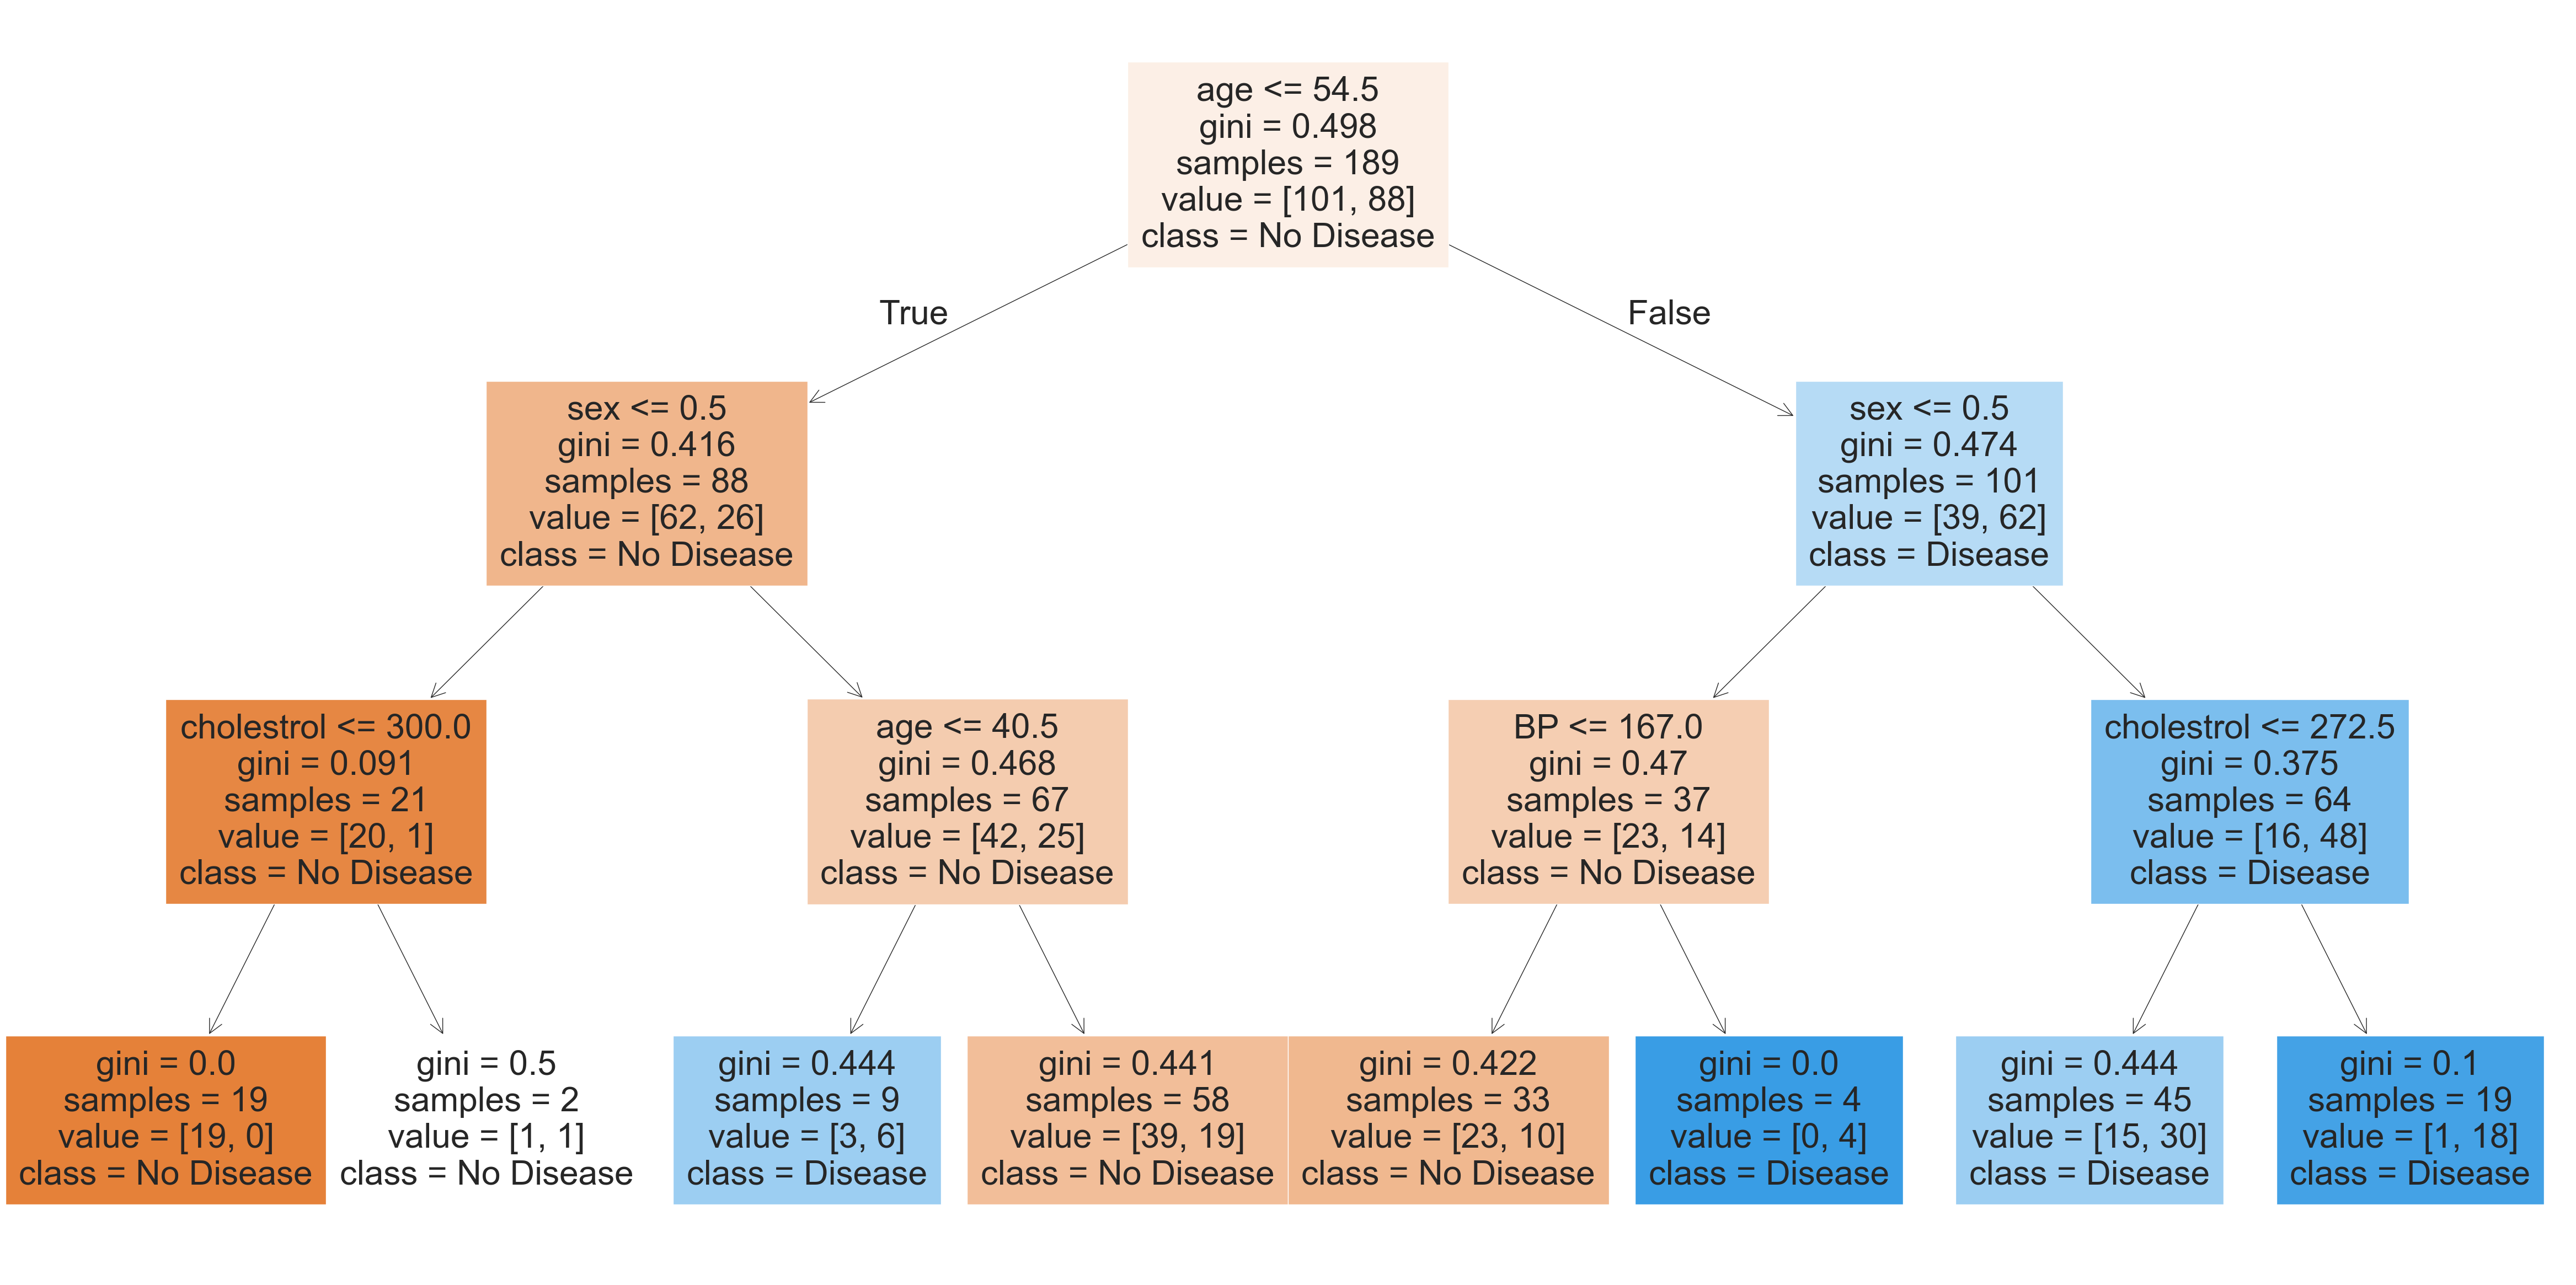

In [21]:
from sklearn.tree import plot_tree

plt.figure(figsize=(60, 30))
plot_tree(
    dt, feature_names=X.columns, class_names=["No Disease", "Disease"], filled=True
)
plt.savefig("decision_tree.png")

In [28]:
%%time
fib = (lambda f: lambda x: f(f, x))(
    lambda self, n: n if n < 2 else self(self, n - 1) + self(self, n - 2)
)

# Generate the first 10 Fibonacci numbers
fib_sequence = [fib(n) for n in range(30)]
print(fib_sequence)

[0, 1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377, 610, 987, 1597, 2584, 4181, 6765, 10946, 17711, 28657, 46368, 75025, 121393, 196418, 317811, 514229]
CPU times: user 119 ms, sys: 2.41 ms, total: 121 ms
Wall time: 121 ms


In [24]:
users = [
    {"name": "John", "age": 17, "email": "john@example.com", "active": True},
    {"name": "Sara", "age": 21, "email": "sara@example.com", "active": True},
    {"name": "Bob", "age": 25, "email": "bob@example.com", "active": False},
]
[u["email"] for u in users if u["active"] and u["age"] > 18]

['sara@example.com']

'9533430321'